# T019 · 分子动力学模拟**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授领域特定的技能，并为研究项目提供流程模板作为起点。作者：- Pietro Gerletti, CADD 研讨会 2020, Charité/FU Berlin- Mareike Leja, 2020/21, 实习于 [Volkamer Lab, Charité](https://volkamerlab.org/)- Jeffrey R Wagner, 2020, [Open Force Field Consortium](https://openforcefield.org/)- David Schaller, 2020/21, [Volkamer Lab, Charité](https://volkamerlab.org/)- Andrea Volkamer, 2020/21, [Volkamer Lab, Charité](https://volkamerlab.org/)

__注意__本教程设计用于 [Google Colab](https://colab.research.google.com/github/volkamerlab/teachopencadd/blob/1bd7cb0c9f6379aebc0c1a0b1c7413685910cffa/teachopencadd/talktorials/019_md_simulation/talktorial.ipynb)。也可以在本地计算机上使用。但如果没有 GPU，执行分子动力学模拟可能需要相当长的时间。另外，请注意本教程**目前无法在 Windows 上运行**（请关注[此问题进展](https://github.com/volkamerlab/teachopencadd/issues/136)）。

## 本教程目标

在本教程中，我们将学习为什么分子动力学（MD）模拟对药物设计很重要，以及执行蛋白质与配体复合物的 MD 模拟需要哪些步骤。激酶 EGFR 将作为模拟的示例系统。

### *理论* 章节内容- 分子动力学- 力场- 边界条件- MD 模拟与药物设计- EGFR 激酶

### *实践* 章节内容- Google Colab 安装- 调整本地安装环境（Linux 或 MacOS）- 导入依赖- 下载 PDB 文件- 准备蛋白质-配体复合物  - 蛋白质准备  - 配体准备  - 合并蛋白质与配体- MD 模拟设置  - 力场  - 系统- 执行 MD 模拟- 下载结果

### 参考文献- MD 模拟在药物发现中影响的综述 ([_J Med Chem_ (2016), **59**(9), 4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684))- MD 模拟背后物理学和最佳实践综述 ([_Living J Comp Mol Sci_ (2019), **1**(1), 5957](https://doi.org/10.33011/livecoms.1.1.5957))- 力场综述 ([_J Chem Inf Model_ (2018), **58**(3), 565-578](https://doi.org/10.1021/acs.jcim.8b00042))- EGFR 在癌症中作用的综述 ([_Cancers (Basel)_ (2017), **9**(5), 52](https://dx.doi.org/10.3390%2Fcancers9050052))- 来自 Pierre-Simon Laplace 的统计知识总结 ([Théorie Analytique des Probabilités _Gauthier-Villars_ (1820), **3**)](https://archive.org/details/uvrescompltesde31fragoog/page/n15/mode/2up)- 灵感来自 Jaime Rodríguez-Guerra 的笔记本 ([github](https://github.com/jaimergp/uab-msc-bioinf/blob/master/MD%20Simulation%20and%20Analysis%20in%20a%20Notebook.ipynb))- [OpenMM](https://github.com/openmm/openmm) 和 [OpenMM Forcefields](https://github.com/openmm/openmmforcefields)、[RDKit](https://github.com/rdkit/rdkit)、[PyPDB](https://github.com/williamgilpin/pypdb)、[MDTraj](https://github.com/mdtraj/mdtraj)、[PDBFixer](https://github.com/openmm/pdbfixer) 的仓库- 关于 [MD 模拟](https://en.wikipedia.org/wiki/Molecular_dynamics)、[AMBER](https://en.wikipedia.org/wiki/AMBER) 和 [力场](https://en.wikipedia.org/wiki/Force_field_(chemistry)) 的维基百科文章

In [1]:
import sys

on_colab = "google.colab" in sys.modules
if on_colab:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 19
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt
    %conda install mdtraj openmm openmmforcefields openff-toolkit pdbfixer pypdb rdkit -y -c conda-forge

## 理论

### 分子动力学

分子动力学是一种分析定义系统中原子和分子运动及相互作用的计算方法。该方法源于理论物理学，于 1950 年代发展起来（Alder 和 Wainwright，[_J Chem Phys_ (1959), **31**(2), 459](https://doi.org/10.1063/1.1730376)），但其背后的思想可以追溯到更早：> 一个智慧体，如果能够在任何时刻理解赋予自然活力的所有力以及组成自然的所有存在物各自的位置，并且如果这个智慧体足够深远，能够对这些数据进行分析，那么它将在一个公式中同时包含宇宙中最大物体的运动和最轻原子的运动：对它而言，没有什么是确定的，未来和过去都将呈现在它眼前。人类智慧在天文学中所达到的完美，为我们提供了这种智慧的一个微弱草图。（Pierre-Simon Laplace，1820）

让我们将 Laplace 的这段话视为分子动力学模拟的思想基础。换句话说，我们可以通过了解系统各组成部分的特征并应用牛顿运动定律来近似系统的行为。通过求解运动方程，我们可以获得系统的分子轨迹，这是一系列包含所有粒子位置、速度以及势能的快照。为此，我们定义称为力场的函数，它们提供了对系统中每个粒子所受所有力的近似描述。然后我们使用数值积分器求解系统的初值问题并获得轨迹。正如听起来那样，这个过程需要相当多的计算能力，直到几年前 MD 才开始得到更广泛的应用，特别是在计算化学和生物学领域，以及药物发现中（[_J Med Chem_ (2016), **59**(9), 4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684)）。

![MD_rotor_250K_1ns.gif](https://github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MD_rotor_250K_1ns.gif)**图 1**：受限纳米孔中三个分子组成的超分子旋转的分子动力学模拟（Palma 等人，via [Wikimedia](https://commons.wikimedia.org/w/index.php?curid=34866205)）。

### 力场

力场描述了原子内部以及分子之间相互作用的力。它们是参数化方程，包含不同力的组成部分（键伸缩、范德华力等）。参数值通常通过实验推导，并根据所涉及的分子和模拟设置，针对每个 MD 场景而变化。结果是系统能量景观的数学描述，其中作用于每个粒子的力来自于势能相对于原子坐标的梯度。有几种可用的力场，各有其特点（[_J Chem Inf Model_ (2018), **58**(3), 565-578](https://doi.org/10.1021/acs.jcim.8b00042)）。在本教程中，我们将使用 AMBER 力场家族的成员，该家族被广泛用于蛋白质的 MD 模拟。其函数形式为：$$V(r^N) = \sum_{i \in  bonds}k_{bi} (l_i-l^0_i)^2 + \sum_{i \in  angles}k_{ai}(\theta_i - \theta^0_i)^2 + \sum_{i\in torsions} \sum_n \frac{1}{2} V_i^n[1+cos(nw_i-\gamma_i)]$$$$+ \sum_{j=1}^{N-1}\sum_{I=j+1}^{N} f_{ij}\in ij [(\frac{r^0_{ij}}{r_{ij}})^{12}-2(\frac{r^0_{ij}}{r_{ij}})^{6}]+\frac{q_iq_j}{4\pi \in_0 r_{ij}}$$

该公式由不同组成部分的总和组成。前三个组成部分包含键长、键角和扭转角的信息（分子内力）。最后一个组成部分描述了分子间的非键合力，如范德华力和静电相互作用。各个参数（用上标 0 表示）取决于所使用的力场，并在 AMBER 力场家族的所有成员之间变化。请注意，这些力场假设粒子具有固定电荷，不允许极化，也不考虑局部电荷如何影响其周围环境。下面的力场组成部分的可视化表示以更直观的方式展示了相同的概念。

![MM_PEF.png](https://github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MM_PEF.png)**图 2**：分子力学力场的组成部分（Edboas via [Wikimedia](https://commons.wikimedia.org/w/index.php?curid=4194424)）。

### 边界条件通常，分子系统在填充有溶剂（如水）的盒子中进行模拟。这些盒子尺寸有限，这会导致盒子边界处或附近的分子出现问题。它们应该与哪些分子相互作用？周期性边界条件可以通过模拟理论上无限的系统来避免此类边界伪影。盒子一个边界处的分子与盒子另一侧边界处的分子相互作用。这模拟了一种情况，即模拟盒被自身的副本包围。在可视化此类 MD 模拟时，我们经常观察到粒子从一侧离开盒子（图 3）。然而，它们同时以相同的速度重新出现在盒子的另一侧。对于周期性边界条件下的模拟，建议使用足够大的模拟盒，使得被模拟的大分子不会与其相邻镜像接触。

![MD_water.gif](https://github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MD_water.gif)**图 3**：周期性边界条件下水分子的分子动力学模拟（Kmckiern via [Wikimedia](https://commons.wikimedia.org/wiki/File:MD_water.gif)）。

### MD 模拟与药物设计MD 模拟为配体与其靶标结合的高度动态过程提供了宝贵的见解。当配体（或药物）在溶液中接近大分子（蛋白质）时，它遇到的是一个处于不断运动状态的结构。此外，配体可能诱导大分子发生构象变化，以最佳方式容纳小分子。这种构象可能无法通过静态方法发现。因此，在静态无配体结构中未观察到，但可以通过 MD 模拟发现的结合位点有时被称为*隐性结合位点*（[_J Med Chem_ (2016), **59**(9), 4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684)）。使用 MD 模拟识别这些结合位点可以启动新的药物发现活动。在药物发现过程的后期，MD 模拟也可用于在执行更昂贵和耗时的*体外*测试之前评估计算识别的小分子的质量。总的来说，MD 模拟是计算药物设计中的宝贵资产。

### EGFR 激酶**表**皮**生**长**因**子**受**体（EGFR）是一个重要的药物靶点，与癌症和炎症有关（[Wikipedia](https://en.wikipedia.org/wiki/Epidermal_growth_factor_receptor)）。它是一种跨膜蛋白，具有细胞外受体结构域和细胞内激酶结构域。内源性配体表皮生长因子的结合通过二聚化和自磷酸化激活激酶结构域。激活的激酶结构域随后可以磷酸化下游信号蛋白，触发 DNA 合成和细胞增殖（[_Cancers (Basel)_ (2017), **9**(5), 52](https://dx.doi.org/10.3390%2Fcancers9050052)）。抑制这种激酶是几种已获批癌症药物的作用机制基础（[DrugBank](https://go.drugbank.com/bio_entities/BE0000767)）。在本教程中，我们使用该激酶的 PDB 结构 **3POZ**，其与小分子抑制剂 **03P** 形成复合物，以执行 MD 模拟（[PDB: 3POZ](https://www.rcsb.org/structure/3poz)）。

![3poz_assembly-1.jpeg](https://github.com/volkamerlab/teachopencadd/raw/ed3b2b6b655589d71355295af4c89363a63558b9/teachopencadd/talktorials/018_md_simulation/images/3poz_assembly-1.jpeg)**图 4**：EGFR 激酶结构域与抑制剂 03P 结合的 3POZ 结构（[PDB: 3POZ](https://www.rcsb.org/structure/3poz)）。

## 实践现在我们将使用分子动力学引擎 [OpenMM](https://github.com/openmm/openmm) 来执行 MD 模拟，这是一个用于分子模拟的高性能工具包。它是开源的，可以用作应用程序或库。我们将把它用作 Python 库。

### 导入依赖

In [2]:
import copy
from pathlib import Path

import requests
from IPython.display import display
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import mdtraj as md
import pdbfixer
import openmm as mm
import openmm.app as app
from openmm import unit
from openff.toolkit.topology import Molecule, Topology
from openmmforcefields.generators import GAFFTemplateGenerator

In [3]:
# 如果数据目录不存在则创建
HERE = Path(_dh[-1])
DATA = HERE / "data"
DATA.mkdir(exist_ok=True)

### 下载 PDB 文件蛋白质数据库（[PDB](https://www.rcsb.org/)）允许通过 URL 轻松下载文件。

In [4]:
pdbid = "3POZ"
ligand_name = "03P"
pdb_path = DATA / f"{pdbid}.pdb"
pdb_url = f"https://files.rcsb.org/download/{pdbid}.pdb"

In [5]:
r = requests.get(pdb_url)
r.raise_for_status()
with open(pdb_path, "wb") as f:
    f.write(r.content)

### 准备蛋白质-配体复合物

#### 蛋白质准备成功模拟的关键部分是正确且完整的系统。从蛋白质数据库检索的晶体结构通常缺少原子（主要是氢），并且可能包含非标准残基。在本教程中，我们将使用 Python 包 [PDBFixer](https://github.com/openmm/pdbfixer) 来准备蛋白质结构。然而，共结晶的配体不能由 [PDBFixer](https://github.com/openmm/pdbfixer) 很好地处理，因此将单独准备。

In [6]:
def prepare_protein(
    pdb_file, ignore_missing_residues=True, ignore_terminal_missing_residues=True, ph=7.0
):
    """
    使用 pdbfixer 从 PDB 文件准备蛋白质。移除杂原子（如配体）并替换非标准残基。
    为现有残基添加缺失的原子。默认忽略缺失残基，但可以选择包含。

    参数
    ----------
    pdb_file: pathlib.Path 或 str
        包含待模拟系统的 PDB 文件。
    ignore_missing_residues: bool, 可选
        是否忽略或构建缺失残基。
    ignore_terminal_missing_residues: bool, 可选
        是否忽略或构建链首尾的缺失残基。
    ph: float, 可选
        用于确定残基质子化状态的 pH 值。

    返回
    -------
    fixer: pdbfixer.pdbfixer.PDBFixer
        准备好的蛋白质系统。
    """
    fixer = pdbfixer.PDBFixer(str(pdb_file))
    fixer.removeHeterogens()  # 共结晶配体对 PDBFixer 来说是未知的
    fixer.findMissingResidues()  # 识别缺失残基，用于后续识别缺失原子

    # 如果忽略末端缺失残基，则从字典中移除
    if ignore_terminal_missing_residues:
        chains = list(fixer.topology.chains())
        keys = fixer.missingResidues.keys()
        for key in list(keys):
            chain = chains[key[0]]
            if key[1] == 0 or key[1] == len(list(chain.residues())):
                del fixer.missingResidues[key]

    # 如果忽略所有缺失残基，则清空字典
    if ignore_missing_residues:
        fixer.missingResidues = {}

    fixer.findNonstandardResidues()  # 查找非标准残基
    fixer.replaceNonstandardResidues()  # 用标准残基替换非标准残基
    fixer.findMissingAtoms()  # 查找缺失的重原子
    fixer.addMissingAtoms()  # 添加缺失的原子和残基
    fixer.addMissingHydrogens(ph)  # 添加缺失的氢原子
    return fixer

In [7]:
# 准备蛋白质，仅构建缺失的非末端残基
prepared_protein = prepare_protein(pdb_path, ignore_missing_residues=False)

#### 配体准备

准备完蛋白质后，我们将注意力转向配体。同样，我们需要添加氢原子，但还需要确保键级正确分配，因为某些 PDB 条目可能包含错误。我们使用 Python 包 [RDKit](https://github.com/rdkit/rdkit)，一个开源化学信息学库。我们将通过 SMILES 字符串向 [RDKit](https://github.com/rdkit/rdkit) 提供正确的质子化状态和键级。每个共结晶配体的未带电异构 SMILES 字符串可以在其各自的 [PDB](https://www.rcsb.org) 条目中找到。PDB 条目 [3POZ](https://www.rcsb.org/structure/3poz) 的配体名称是 [03P](https://www.rcsb.org/ligand/03P)。如果配体可能以其带电形式或特定互变异构体结合，则这些特征需要合并到 SMILES 字符串中。

In [8]:
def prepare_ligand(pdb_file, resname, smiles, depict=True):
    """
    通过添加氢原子和分配键级，从 PDB 文件准备配体。
    准备前后的配体以 2D 形式呈现，以便检查结果。
    非常感谢 @j-wags 的建议。

    参数
    ----------
    pdb_file: pathlib.PosixPath
       包含目标配体的 PDB 文件。
    resname: str
        配体的三字符残基名称。
    smiles : str
        配体的 SMILES 字符串，提供正确的质子化和键级信息。
    depict: bool, 可选
        是否显示配体的 2D 表示。

    返回
    -------
    prepared_ligand: rdkit.Chem.rdchem.Mol
        准备好的配体。
    """
    # 分离分子
    rdkit_mol = Chem.MolFromPDBFile(str(pdb_file))
    rdkit_mol_split = Chem.rdmolops.SplitMolByPDBResidues(rdkit_mol)

    # 提取配体并移除已存在的氢原子
    ligand = rdkit_mol_split[resname]
    ligand = Chem.RemoveHs(ligand)

    # 从模板分配键级
    reference_mol = Chem.MolFromSmiles(smiles)
    prepared_ligand = AllChem.AssignBondOrdersFromTemplate(reference_mol, ligand)
    prepared_ligand.AddConformer(ligand.GetConformer(0))

    # 对配体质子化
    prepared_ligand = Chem.rdmolops.AddHs(prepared_ligand, addCoords=True)
    prepared_ligand = Chem.MolFromMolBlock(Chem.MolToMolBlock(prepared_ligand))

    # 2D 展示
    if depict:
        ligand_2d = copy.deepcopy(ligand)
        prepared_ligand_2d = copy.deepcopy(prepared_ligand)
        AllChem.Compute2DCoords(ligand_2d)
        AllChem.Compute2DCoords(prepared_ligand_2d)
        display(
            Draw.MolsToGridImage(
                [ligand_2d, prepared_ligand_2d], molsPerRow=2, legends=["original", "prepared"]
            )
        )

    # 返回配体
    return prepared_ligand

调用此函数并使用从 PDB 条目 [03P](https://www.rcsb.org/ligand/03P) 获取的异构 SMILES 字符串，将返回正确准备的配体。打印出原始配体和准备后配体的 2D 表示以供检查。

[10:10:57] WARNING: More than one matching pattern found - picking one



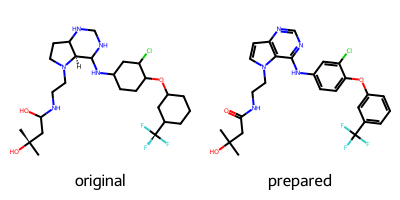

In [9]:
smiles = "CC(C)(O)CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc(c4)C(F)(F)F)c(Cl)c3)c12"
rdkit_ligand = prepare_ligand(pdb_path, ligand_name, smiles)

#### 合并蛋白质与配体下一步，我们想要使用 Python 包 [MDTraj](https://github.com/mdtraj/mdtraj) 合并准备好的蛋白质和配体结构。[MDTraj](https://github.com/mdtraj/mdtraj) 可以处理准备好的蛋白质，它当前是一个 [PDBFixer](https://github.com/openmm/pdbfixer) 分子，这种格式具有与 [OpenMM Modeller](http://docs.openmm.org/latest/userguide/application.html#model-building-and-editing) 拓扑和位置类似且通常可互换的拓扑和原子位置。然而，对于配体，我们需要进行多次转换，因为它当前是一个 [RDKit](https://github.com/rdkit/rdkit) 分子。

In [10]:
def rdkit_to_openmm(rdkit_mol, name="LIG"):
    """
    将 RDKit 分子转换为 OpenMM 分子。
    灵感来自 @hannahbrucemcdonald 和 @glass-w。

    参数
    ----------
    rdkit_mol: rdkit.Chem.rdchem.Mol
        要转换的 RDKit 分子。
    name: str
        分子名称。

    返回
    -------
    omm_molecule: openmm.app.Modeller
        包含目标分子的 OpenMM modeller 对象。
    """
    # 将 RDKit 转换为 OpenFF
    off_mol = Molecule.from_rdkit(rdkit_mol)

    # 为分子添加名称
    off_mol.name = name

    # 为原子添加名称
    element_counter_dict = {}
    for off_atom, rdkit_atom in zip(off_mol.atoms, rdkit_mol.GetAtoms()):
        element = rdkit_atom.GetSymbol()
        if element in element_counter_dict.keys():
            element_counter_dict[element] += 1
        else:
            element_counter_dict[element] = 1
        off_atom.name = element + str(element_counter_dict[element])

    # 从 OpenFF 转换为 OpenMM
    off_mol_topology = off_mol.to_topology()
    mol_topology = off_mol_topology.to_openmm()
    mol_positions = off_mol.conformers[0]

    # 将单位从 Ångström 转换为 nm
    # 因为 OpenMM 使用 nm 作为单位
    mol_positions = mol_positions.to("nanometers")

    # 将拓扑和位置合并到 modeller 对象中
    omm_mol = app.Modeller(mol_topology, mol_positions)

    return omm_mol

In [11]:
omm_ligand = rdkit_to_openmm(rdkit_ligand, ligand_name)

现在蛋白质和配体都处于 [OpenMM](https://github.com/openmm/openmm) 类似格式，可以通过 [MDTraj](https://github.com/mdtraj/mdtraj) 合并。

In [12]:
def merge_protein_and_ligand(protein, ligand):
    """
    合并两个 OpenMM 对象。

    参数
    ----------
    protein: pdbfixer.pdbfixer.PDBFixer
        要合并的蛋白质。
    ligand: openmm.app.Modeller
        要合并的配体。

    返回
    -------
    complex_topology: openmm.app.topology.Topology
        合并后的拓扑。
    complex_positions: openmm.unit.quantity.Quantity
        合并后的位置。
    """
    # 合并拓扑
    md_protein_topology = md.Topology.from_openmm(protein.topology)  # 使用 mdtraj 处理蛋白质拓扑
    md_ligand_topology = md.Topology.from_openmm(ligand.topology)  # 使用 mdtraj 处理配体拓扑
    md_complex_topology = md_protein_topology.join(md_ligand_topology)  # 合并到一起
    complex_topology = md_complex_topology.to_openmm()

    # 合并位置
    total_atoms = len(protein.positions) + len(ligand.positions)

    # 创建数组存储所有原子位置（包含值和单位的元组）
    # 这些称为 OpenMM Quantities
    complex_positions = unit.Quantity(np.zeros([total_atoms, 3]), unit=unit.nanometers)
    complex_positions[: len(protein.positions)] = protein.positions  # 添加蛋白质位置
    complex_positions[len(protein.positions) :] = ligand.positions  # 添加配体位置

    return complex_topology, complex_positions

In [13]:
complex_topology, complex_positions = merge_protein_and_ligand(prepared_protein, omm_ligand)

/home/michael/.teachopencadd_envs/teachopencadd_T019_py312/lib/python3.12/site-packages/openmm/unit/quantity.py:750: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  self._value[key] = value / self.unit


In [14]:
print("Complex topology has", complex_topology.getNumAtoms(), "atoms.")
# NBVAL_CHECK_OUTPUT

Complex topology has 5561 atoms.


### MD 模拟设置现在我们可以使用准备好的复合物来设置 MD 模拟。

#### 力场常见的力场如 AMBER 具有氨基酸、核酸、水和离子的参数，通常提供多种选项供根据目标选择。我们使用随 OpenMM 提供的 `amber14-all.xml` 力场文件，其中包含蛋白质、DNA、RNA 和脂质的参数。对于溶剂化，我们使用标准的三位点[水模型](https://en.wikipedia.org/wiki/Water_model) [**TIP3P**](https://aip.scitation.org/doi/10.1063/1.445869)。然而，配体的参数不包括在内。为了生成这些参数，我们可以使用**通**用 **AMBER** **力**场 （[GAFF](http://ambermd.org/antechamber/gaff.html)），它在 Python 包 [OpenMM Forcefields](https://github.com/openmm/openmmforcefields) 中实现。以下函数生成一个包含标准 AMBER 参数的力场对象，并在需要时额外包含一个小分子的参数。

In [15]:
def generate_forcefield(
    rdkit_mol=None, protein_ff="amber14-all.xml", solvent_ff="amber14/tip3pfb.xml"
):
    """
    生成 OpenMM 力场对象并注册一个小分子。

    参数
    ----------
    rdkit_mol: rdkit.Chem.rdchem.Mol
        要在力场中注册的小分子。
    protein_ff: string
        力场名称。
    solvent_ff: string
        溶剂力场名称。

    返回
    -------
    forcefield: openmm.app.Forcefield
        已注册小分子的力场。
    """
    forcefield = app.ForceField(protein_ff, solvent_ff)

    if rdkit_mol is not None:
        gaff = GAFFTemplateGenerator(
            forcefield="gaff-2.2.20",
            molecules=Molecule.from_rdkit(rdkit_mol, allow_undefined_stereo=True),
        )
        forcefield.registerTemplateGenerator(gaff.generator)

    return forcefield

In [16]:
forcefield = generate_forcefield(rdkit_ligand)

#### 系统

使用我们配置好的力场，我们现在可以使用 [OpenMM Modeller](http://docs.openmm.org/latest/userguide/application.html#model-building-and-editing) 类创建 MD 环境，即一个包含复合物并填充溶剂的模拟盒。标准溶剂是含有指定量离子的水。盒子的尺寸可以通过多种方式确定。我们使用 padding 来定义它，这会产生一个立方体盒子，其尺寸取决于复合物的最大维度。> 注意：此步骤可能需要很长时间（数分钟），具体取决于您的硬件。

In [17]:
modeller = app.Modeller(complex_topology, complex_positions)
modeller.addSolvent(forcefield, padding=1.0 * unit.nanometers, ionicStrength=0.15 * unit.molar)

有了我们的溶剂化系统和力场，我们最终可以创建一个 [OpenMM System](http://docs.openmm.org/development/api-python/generated/openmm.openmm.System.html#openmm.openmm.System) 并设置模拟。除了系统之外，模拟还需要一个积分器。[OpenMM Integrator](http://docs.openmm.org/development/api-python/library.html#integrators) 定义了通过积分运动方程来模拟系统的方法。所选的 **Langevin 积分器** 使用 Langevin 方程。所有不同类型积分器的列表可以在 [OpenMM 文档](http://docs.openmm.org/development/api-python/library.html#integrators) 中找到。要深入了解 **Langevin 积分器**，我们建议阅读关于 Langevin 方程的内容，例如在 [Wikipedia](https://en.wikipedia.org/wiki/Langevin_equation) 上。

In [18]:
system = forcefield.createSystem(modeller.topology, nonbondedMethod=app.PME)
integrator = mm.LangevinIntegrator(
    300 * unit.kelvin, 1.0 / unit.picoseconds, 2.0 * unit.femtoseconds
)
simulation = app.Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)

### 执行 MD 模拟现在一切都已设置好，我们可以执行模拟了。我们需要设置起始位置并最小化系统的能量，以获得低能量的起始构象，这对于减少因严重原子碰撞而导致模拟失败的可能性很重要。能量最小化的系统将被保存。

In [19]:
simulation.minimizeEnergy()
with open(DATA / "topology.pdb", "w") as pdb_file:
    app.PDBFile.writeFile(
        simulation.topology,
        simulation.context.getState(getPositions=True, enforcePeriodicBox=True).getPositions(),
        file=pdb_file,
        keepIds=True,
    )

一旦最小化完成，我们就可以执行 MD 模拟。在本教程中，我们将进行一个简短的模拟以作说明。用于研究目的的模拟跨越数纳秒，甚至达到微秒。我们将仅模拟 100 ps 的分子动力学，对应每步 2 fs 的 50k 步。我们每 10 ps（5000 步）保存分子"快照"，总共 10 帧。结果保存在 .xtc 文件中，其中包含所有原子在给定时间点的坐标。结合之前写入的能量最小化系统的 PDB 文件，它为我们提供了后续分析所需的所有信息。**注意**：如果不在 Google Colab 上运行，本教程将仅生成 20 fs 的轨迹。但是，如果您有可用的 GPU，也可以增加模拟时间。

In [20]:
# 输出设置
if on_colab:
    steps = 50000  # 对应 100 ps
    write_interval = 5000  # 每 10 ps 写入一次
    log_interval = 2500  # 每 5 ps 记录进度到标准输出
else:
    steps = 10  # 对应 20 fs
    write_interval = 1  # 每 2 fs 写入一次
    log_interval = 1  # 每 2 fs 记录进度到标准输出
simulation.reporters.append(
    md.reporters.XTCReporter(file=str(DATA / "trajectory.xtc"), reportInterval=write_interval)
)
simulation.reporters.append(
    app.StateDataReporter(
        sys.stdout,
        log_interval,
        step=True,
        potentialEnergy=True,
        temperature=True,
        progress=True,
        remainingTime=True,
        speed=True,
        totalSteps=steps,
        separator="\t",
    )
)

系统中所有粒子的速度从给定温度下的分布中随机选择。我们选择 300 开尔文，这比室温高出几度。生成一个随机种子，但也可以明确指定以重现结果。然后通过执行之前定义的步数来进行模拟。

In [21]:
simulation.context.setVelocitiesToTemperature(300 * unit.kelvin)
simulation.step(steps)  # 执行模拟

#"Progress (%)"	"Step"	"Potential Energy (kJ/mole)"	"Temperature (K)"	"Speed (ns/day)"	"Time Remaining"
10.0%	1	-911672.8833984158	300.58994432283663	0	--
20.0%	2	-898806.4210639504	267.2506776332451	1.78	0:00
30.0%	3	-883111.4814176012	238.60290950665717	1.73	0:00
40.0%	4	-867596.4630740668	196.76725273444427	1.68	0:00
50.0%	5	-862553.2471993582	175.87229216182052	1.6	0:00
60.0%	6	-854763.8296435549	163.39398429953755	1.54	0:00
70.0%	7	-852074.9736099411	147.9384677561452	1.5	0:00
80.0%	8	-855085.7518770137	152.24611569256365	1.5	0:00
90.0%	9	-856760.1494785415	157.91401106119835	1.49	0:00
100.0%	10	-861616.5007841537	165.39716192526913	1.49	0:00


In [22]:
# 检查轨迹文件是否存在且不为空
(DATA / "trajectory.xtc").stat().st_size > 0
# NBVAL_CHECK_OUTPUT

True

### 下载结果如果您在 Google Colab 上运行，可以执行以下单元格来下载 MD 模拟结果。

In [23]:
if on_colab:
    files.download(DATA / "topology.pdb")
    files.download(DATA / "trajectory.xtc")

## 讨论我们已成功执行了蛋白质-配体复合物的 MD 模拟。然而，我们仅模拟了相当短的时间，以保持教程的执行时间较短。要解决药物设计中的关键问题，通常需要更长的模拟。MD 模拟的计算成本仍然过高，无法用于此目的。因此，人们开发了所谓的增强采样方法，旨在加速构象采样。一些最常用的方法在下面的**延伸阅读**部分讨论。此外，我们没有包括平衡步骤，该步骤通常用于在开始模拟前将系统从 0 K 缓慢加热到 300 K，并且在模拟包括脂质双层的更敏感系统时可能很重要。配体和蛋白质的质子化是分开进行的，这是次优的，因为蛋白质残基和配体的质子化状态相互影响。然而，我们没有找到满足所有要求的免费开源解决方案。非常欢迎建议！如果您想学习如何可视化和分析轨迹，可以参考本仓库中的**教程 T020**。

## 测验* AMBER 力场考虑了哪些分子间和分子内力？您能想到哪些力没有被考虑吗？* 使用相同参数运行本教程两次，您会期望看到完全相同的模拟结果吗？* 尝试对一个没有配体的蛋白质进行短时间（10ps，每 1ps 快照）的模拟。您可以在 [PDB](https://www.rcsb.org/) 上找到各种结构，或者使用 EGFR 激酶并移除配体。

## 延伸阅读

### 增强采样方法理论上，无偏的 MD 模拟应该能够模拟药物分子及其大分子靶标的结合和解离事件。然而，结合和解离事件的时间尺度在毫秒到秒的范围内。增强采样方法旨在加速构象采样（[_J Med Chem._ 2016, **59(9)**, 4035-61](https://doi.org/10.1021/acs.jmedchem.5b01684)）。其中一种是**自由能微扰（FEP）**（也称为炼金术自由能计算），它计算从状态 A 到另一个状态 B 时的自由能差。它通常用于先导化合物优化中，以评估配体的微小修改，这些修改可能会增强对目标靶标的结合亲和力。通过模拟几个中间（"炼金术"）状态，状态 A 的配体逐渐转变为状态 B 的配体（[alchemistry](http://www.alchemistry.org/wiki/Main_Page)）。另一种自由能计算技术是**伞形采样（US）**。US 通过使用能量偏倚执行分阶段模拟，强制沿集体变量（CV）进行采样。偏倚通常采用谐振势的形式，因此称为"伞形"。其目标是对沿 CV 的高能区域进行采样。然而，在药物设计中的应用受到高计算成本的限制。相比之下，**受控 MD（SMD）**采用不同的方法：它对系统施加外力。这些力是时间依赖性的，并促进配体从靶标上解离。SMD 计算施加在系统上的最终力。然后可以使用解离力谱来筛选对接计算得到的命中化合物，并区分活性分子和非活性分子。